In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd 
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [3]:
stock= yf.download ("AAPL", start = "2018-01-01",end = "2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297150,40.839968,40.233980,40.367342,118071600
2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
2018-01-05,40.945251,41.031820,40.489005,40.580254,94640000
2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200


In [5]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-24,256.797211,256.807136,253.903002,254.101927,23234700
2024-12-26,257.612732,258.686881,256.230300,256.787255,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300
2024-12-30,250.829788,252.122728,249.387669,250.859624,35557500
2024-12-31,249.059464,251.903926,248.074837,251.068493,39480700


In [6]:
stock.info

<bound method DataFrame.info of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2018-01-02   40.304176   40.313537   39.602258   39.812835  102223600
2018-01-03   40.297150   40.839968   40.233980   40.367342  118071600
2018-01-04   40.484337   40.587286   40.262063   40.369689   89738400
2018-01-05   40.945251   41.031820   40.489005   40.580254   94640000
2018-01-08   40.793182   41.087987   40.694911   40.793182   82271200
...                ...         ...         ...         ...        ...
2024-12-24  256.797211  256.807136  253.903002  254.101927   23234700
2024-12-26  257.612732  258.686881  256.230300  256.787255   27237100
2024-12-27  254.201370  257.294489  251.685117  256.429191   42355300
2024-12-30  250.829788  252.122728  249.387669  250.859624   35557500
2024-12-31  249.059464  251.903926  248.074837  251.068493

In [7]:
data =stock [['Close']]

In [8]:
data.columns

MultiIndex([('Close', 'AAPL')],
           names=['Price', 'Ticker'])

In [9]:
data['Prediction'] = data['Close'].shift(-1)
data.dropna(inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_10520\1181397969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Prediction'] = data['Close'].shift(-1)
C:\Users\user\AppData\Local\Temp\ipykernel_10520\1181397969.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [11]:
X = data[['Close']]
y = data['Prediction']


In [12]:
print(data.shape)
print(data.head())


(1760, 2)
Price           Close Prediction
Ticker           AAPL           
Date                            
2018-01-02  40.304176  40.297150
2018-01-03  40.297150  40.484337
2018-01-04  40.484337  40.945251
2018-01-05  40.945251  40.793182
2018-01-08  40.793182  40.788506


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
predictions = model.predict(X_test)


In [16]:
mse =  mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mse 


7.190225006557387

In [17]:
rmse

2.681459491873295

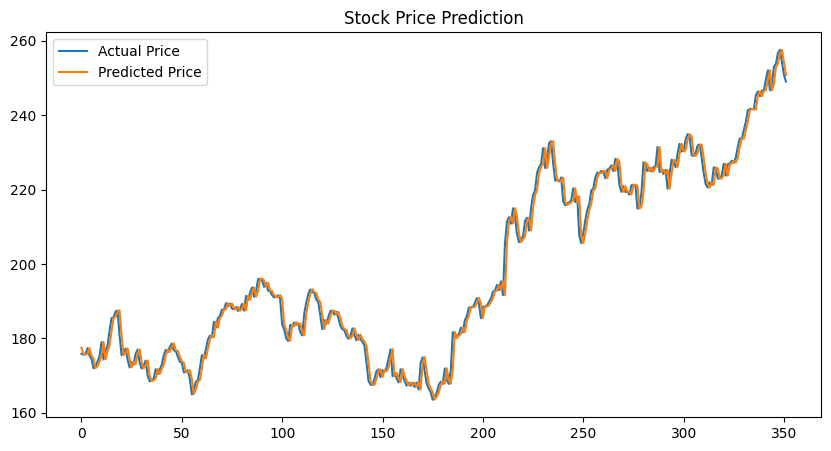

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()


In [19]:
if len(data) > 0:
    last_close = data[['Close']].iloc[-1].values.reshape(1, -1)
    next_price = model.predict(last_close)
    print("Predicted Next Day Price:", next_price[0])
else:
    print("Dataset is empty. Cannot predict next day price.")


Predicted Next Day Price: 250.81849408942008
